<a href="https://colab.research.google.com/github/Umang-Gisma/M507C/blob/main/M507_24_04_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptrons
You should build an end-to-end machine learning pipeline using a perceptron model. In particular, you should do the following:
- Load the [`mnist`](https://github.com/m-mahdavi/teaching/blob/main/datasets/mnist.csv) dataset using [Pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). You can find this dataset in the datasets folder.
- Split the dataset into training and test sets using [Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).
- Build an end-to-end machine learning pipeline, including a [perceptron](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html) model.
- Optimize your pipeline by validating your design decisions.
- Test the best pipeline on the test set and report various [evaluation metrics](https://scikit-learn.org/0.15/modules/model_evaluation.html).  
- Check the documentation to identify the most important hyperparameters, attributes, and methods of the model. Use them in practice.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/m-mahdavi/teaching/refs/heads/main/datasets/mnist.csv")
df.head()

,id,class,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,31953,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,34452,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,60897,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36953,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1981,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3200, 785), Test: (800, 785)


In [ ]:
demo = Perceptron(random_state=42, max_iter=5)
demo.fit(X_train, y_train)

print(f"coef_ shape    : {demo.coef_.shape}")
print(f"intercept_ shape: {demo.intercept_.shape}")
print(f"n_iter_        : {demo.n_iter_}")
print(f"classes_       : {demo.classes_}")

coef_ shape    : (10, 785)
intercept_ shape: (10,)
n_iter_        : 5
classes_       : [0 1 2 3 4 5 6 7 8 9]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    Perceptron(random_state=42, max_iter=1000, tol=1e-3))
])

baseline_pipeline.fit(X_train, y_train)
cv_scores = cross_val_score(
    baseline_pipeline, X_train, y_train,
    cv=5, scoring='accuracy', n_jobs=-1
)

print(f"CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores : {[round(s,4) for s in cv_scores]}")

CV Accuracy : 0.8272 ± 0.0206
Fold scores : [np.float64(0.8328), np.float64(0.8188), np.float64(0.8562), np.float64(0.7938), np.float64(0.8344)]


In [ ]:
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    Perceptron(penalty='l2', random_state=42, tol=1e-3))
])

param_grid = {
    'clf__alpha':    [1e-5, 1e-4, 1e-3],
    'clf__max_iter': [500, 1000, 2000],
    'clf__eta0':     [0.5, 1.0],
}

grid_search = GridSearchCV(
    best_pipeline, param_grid,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest params   : {grid_search.best_params_}")
print(f"Best CV acc   : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params   : {'clf__alpha': 0.0001, 'clf__eta0': 0.5, 'clf__max_iter': 500}
Best CV acc   : 0.8444


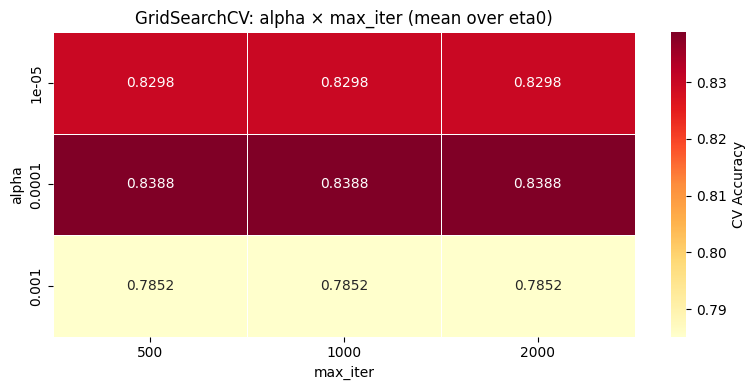

In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results.groupby(
    ['param_clf__alpha', 'param_clf__max_iter']
)['mean_test_score'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CV Accuracy'})
ax.set_title('GridSearchCV: alpha × max_iter (mean over eta0)', fontsize=12)
ax.set_xlabel('max_iter')
ax.set_ylabel('alpha')
plt.tight_layout()
plt.show()

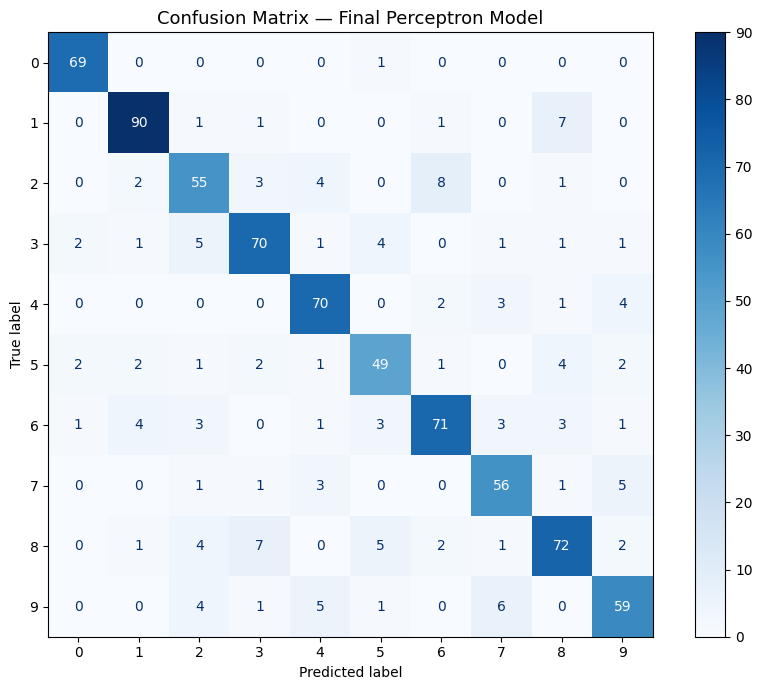

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=range(10))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Final Perceptron Model', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
final_model = grid_search.best_estimator_
y_pred = final_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy : {test_acc:.4f}")
print("\n" + "=" * 55)
print(classification_report(y_test, y_pred, digits=4))

Test Accuracy : 0.8263

              precision    recall  f1-score   support

           0     0.9324    0.9857    0.9583        70
           1     0.9000    0.9000    0.9000       100
           2     0.7432    0.7534    0.7483        73
           3     0.8235    0.8140    0.8187        86
           4     0.8235    0.8750    0.8485        80
           5     0.7778    0.7656    0.7717        64
           6     0.8353    0.7889    0.8114        90
           7     0.8000    0.8358    0.8175        67
           8     0.8000    0.7660    0.7826        94
           9     0.7973    0.7763    0.7867        76

    accuracy                         0.8263       800
   macro avg     0.8233    0.8261    0.8244       800
weighted avg     0.8257    0.8263    0.8257       800

